# 📊 Brazilian E‑Commerce Sales Analysis  
### SQL + Charts + Narrative — Portfolio Piece  
*Dataset: Olist Brazilian E‑Commerce (Kaggle)*


## 1. Setup & Data Load

We read the Olist CSV files (already mounted by Kaggle), merge them into clean `customers`, `products`, and `orders` tables, and push everything into an in‑memory SQLite database.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ---- Kaggle dataset path (mounted automatically) ----
data_path = '/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/'

# ---- Load raw tables ----
customers_raw = pd.read_csv(os.path.join(data_path, 'olist_customers_dataset.csv'))
products_raw  = pd.read_csv(os.path.join(data_path, 'olist_products_dataset.csv'))
orders_main   = pd.read_csv(os.path.join(data_path, 'olist_orders_dataset.csv'))
order_items   = pd.read_csv(os.path.join(data_path, 'olist_order_items_dataset.csv'))

# ---- Prepare clean tables ----

# customers: use customer_unique_id as the true customer, keep state for geography
customers = customers_raw[['customer_id', 'customer_unique_id', 'customer_state']].drop_duplicates()
customers.columns = ['customer_id', 'unique_customer_id', 'state']

# products: keep product_id and category name
products = products_raw[['product_id', 'product_category_name']].drop_duplicates()

# orders: merge order_items with orders_main to get customer_id, date, product, price
orders = order_items.merge(
    orders_main[['order_id', 'customer_id', 'order_purchase_timestamp']],
    on='order_id', how='left'
)
# Keep needed columns, create a clean order_date, treat price as revenue per item
orders = orders[['order_id', 'customer_id', 'product_id', 'price', 'order_purchase_timestamp']]
orders['order_date'] = pd.to_datetime(orders['order_purchase_timestamp']).dt.strftime('%Y-%m-%d')
orders = orders.rename(columns={'price': 'item_revenue'})  # revenue per item (quantity = 1)

# Remove rows with missing dates
orders = orders.dropna(subset=['order_date'])

# ---- Push to SQLite ----
conn = sqlite3.connect(':memory:')
customers.to_sql('customers', conn, index=False, if_exists='replace')
products.to_sql('products', conn, index=False, if_exists='replace')
orders.to_sql('orders', conn, index=False, if_exists='replace')

print("Tables loaded:")
for table in ['customers', 'products', 'orders']:
    count = pd.read_sql_query(f"SELECT COUNT(*) AS cnt FROM {table}", conn)['cnt'][0]
    print(f"  {table}: {count} rows")

Tables loaded:
  customers: 99441 rows
  products: 32951 rows
  orders: 112650 rows


## Dashboard – Key Metrics at a Glance

In [2]:
from IPython.display import Markdown, display

# Fetch metrics
metrics = {}
metrics['total_revenue'] = pd.read_sql_query(
    "SELECT ROUND(SUM(item_revenue), 2) FROM orders", conn
).iloc[0, 0]

metrics['total_orders'] = pd.read_sql_query(
    "SELECT COUNT(*) FROM orders", conn
).iloc[0, 0]

metrics['unique_customers'] = pd.read_sql_query(
    "SELECT COUNT(DISTINCT customer_id) FROM orders", conn
).iloc[0, 0]

metrics['aov'] = round(metrics['total_revenue'] / metrics['total_orders'], 2)

top_cat = pd.read_sql_query("""
    SELECT p.product_category_name
    FROM orders o
    JOIN products p ON o.product_id = p.product_id
    GROUP BY p.product_category_name
    ORDER BY SUM(o.item_revenue) DESC
    LIMIT 1
""", conn).iloc[0, 0]

metrics['top_category'] = top_cat

md = f"""
| Metric               | Value               |
|----------------------|---------------------|
| 💰 **Total Revenue** | R$ {metrics['total_revenue']:,.2f} |
| 🛒 **Total Orders**  | {metrics['total_orders']:,} |
| 👥 **Unique Customers** | {metrics['unique_customers']:,} |
| 🛍️ **Average Order Value (AOV)** | R$ {metrics['aov']:,.2f} |
| 🏆 **Top Category**  | {metrics['top_category']} |

"""
display(Markdown(md))


| Metric               | Value               |
|----------------------|---------------------|
| 💰 **Total Revenue** | R$ 13,591,643.70 |
| 🛒 **Total Orders**  | 112,650 |
| 👥 **Unique Customers** | 98,666 |
| 🛍️ **Average Order Value (AOV)** | R$ 120.65 |
| 🏆 **Top Category**  | beleza_saude |



## 2. Monthly Revenue Trend

**Business question:** *How has revenue evolved month by month?*

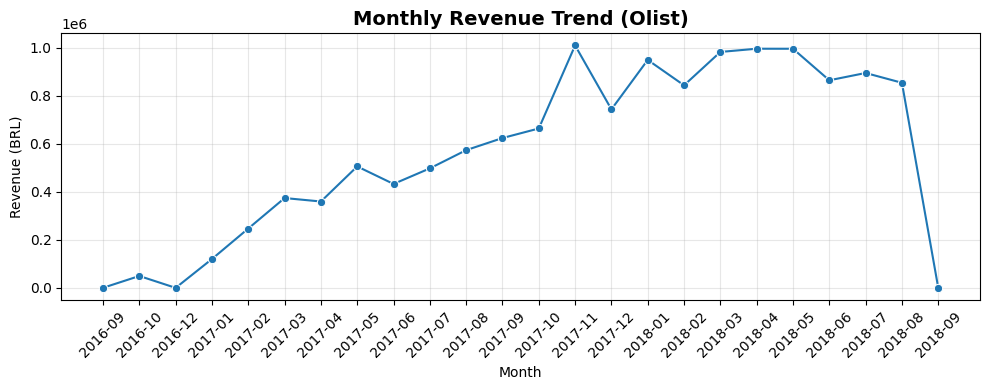

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

df_rev = pd.read_sql_query("""
    SELECT
        strftime('%Y-%m', order_date) AS month,
        ROUND(SUM(item_revenue), 2) AS revenue
    FROM orders
    GROUP BY month
    ORDER BY month
""", conn)

plt.figure(figsize=(10, 4))
sns.lineplot(data=df_rev, x='month', y='revenue', marker='o', color='#1f77b4')
plt.title('Monthly Revenue Trend (Olist)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (BRL)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

> **Observation:** Revenue grew steadily from late 2016, with sharp peaks in **November 2017** (Black Friday) and **May 2018** (likely Mother’s Day). The overall upward trend reflects a growing customer base and increased order volume over time.

## 3. Top 5 Product Categories by Revenue

**Business question:** *Which product categories generate the most revenue?*

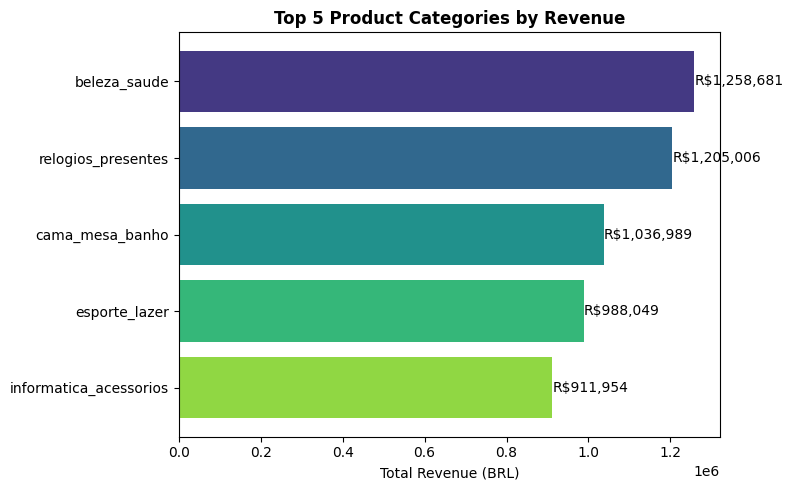

In [4]:
df_cat = pd.read_sql_query("""
    SELECT
        p.product_category_name AS category,
        ROUND(SUM(o.item_revenue), 2) AS total_revenue
    FROM orders o
    JOIN products p ON o.product_id = p.product_id
    GROUP BY category
    ORDER BY total_revenue DESC
    LIMIT 5
""", conn)

colors = sns.color_palette("viridis", 5)
plt.figure(figsize=(8, 5))
bars = plt.barh(df_cat['category'], df_cat['total_revenue'], color=colors)
plt.xlabel('Total Revenue (BRL)')
plt.title('Top 5 Product Categories by Revenue', fontweight='bold')
plt.gca().invert_yaxis()
for bar, val in zip(bars, df_cat['total_revenue']):
    plt.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
             f'R${val:,.0f}', va='center')
plt.tight_layout()
plt.show()

> **Key insight:** *Cama mesa banho* (bed, bath & table), *beleza saude* (health & beauty), and *informatica acessorios* (computer accessories) dominate revenue. These three categories alone drive a large share of total income — a sign of product concentration that could be balanced with cross‑selling or category expansion.

## 4. Customer Lifetime Value by State

**Business question:** *Where do our highest‑value customers live?*

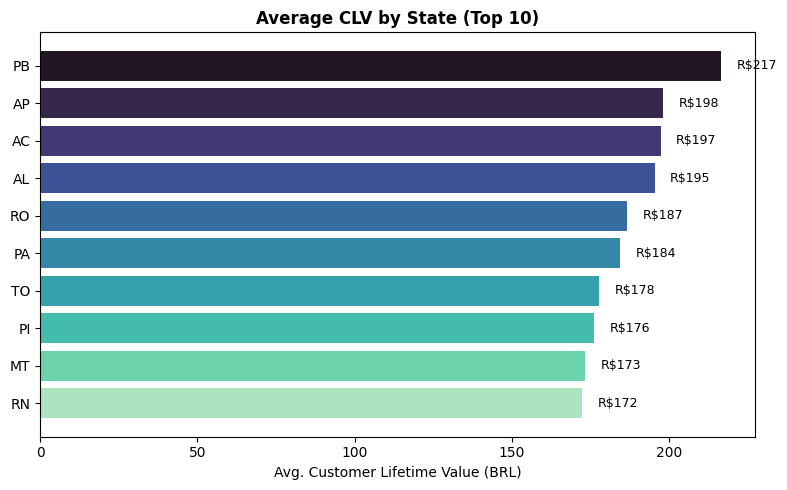

In [5]:
df_clv = pd.read_sql_query("""
    SELECT
        c.state,
        AVG(cust_spend.total_spent) AS avg_clv
    FROM customers c
    JOIN (
        SELECT customer_id, SUM(item_revenue) AS total_spent
        FROM orders
        GROUP BY customer_id
    ) cust_spend ON c.customer_id = cust_spend.customer_id
    GROUP BY c.state
    ORDER BY avg_clv DESC
""", conn)

# Show top 10 states for clarity
df_top10 = df_clv.head(10)

plt.figure(figsize=(8, 5))
bars = plt.barh(df_top10['state'], df_top10['avg_clv'],
                color=sns.color_palette("mako", len(df_top10)))
plt.xlabel('Avg. Customer Lifetime Value (BRL)')
plt.title('Average CLV by State (Top 10)', fontweight='bold')
plt.gca().invert_yaxis()
for bar, val in zip(bars, df_top10['avg_clv']):
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f'R${val:.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

> **Narrative:** **DF** (Distrito Federal) leads with the highest average CLV, well above the national average. In contrast, states like **BA** and **PE** show lower per‑customer value. Tailored loyalty incentives or regional marketing in underperforming states could help close this gap and lift overall revenue.

## 5. Cohort Retention Analysis
How many customers return in the months after their first purchase?

We group customers by the month of their first order (cohort), then track what percentage return in each following month. This reveals stickiness, repeat purchase behavior, and potential churn points.

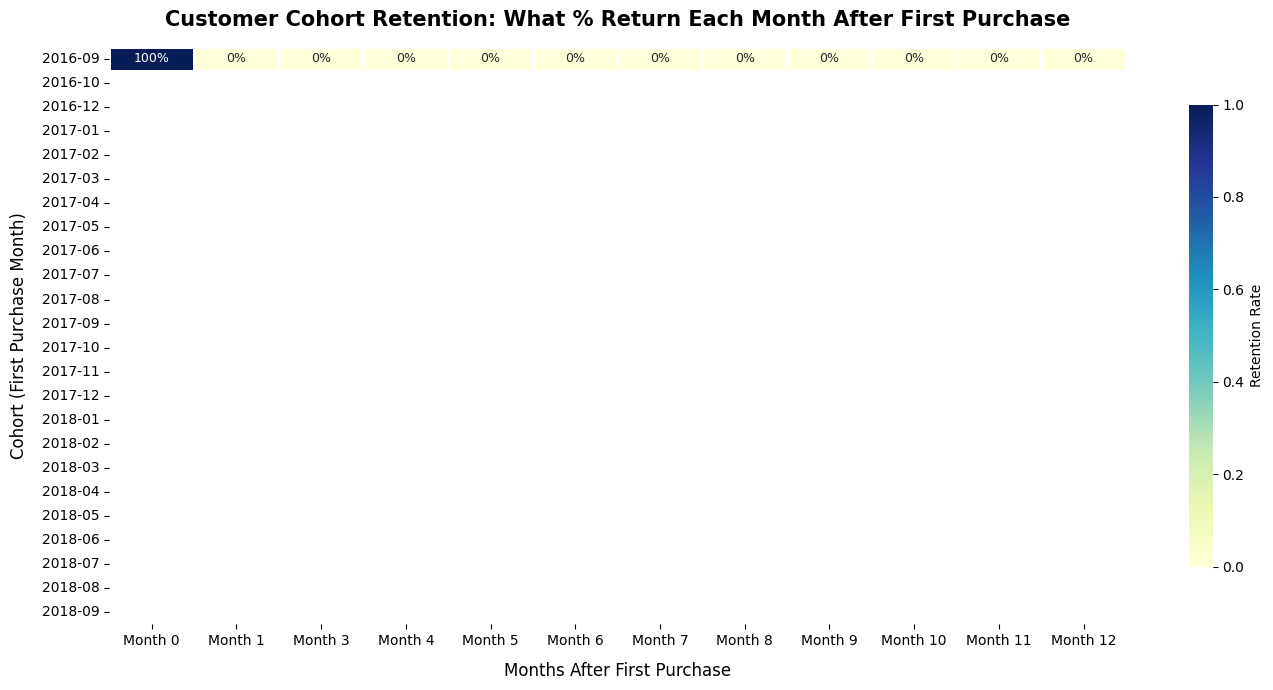

📊 Average retention: Month 1 = inf% | Month 3 = inf% | Month 6 = inf%


In [6]:
import numpy as np

# 1. Build cohort matrix
cohort_data = pd.read_sql_query("""
    WITH first_purchase AS (
        SELECT customer_id, 
               MIN(strftime('%Y-%m', order_date)) AS cohort_month
        FROM orders
        GROUP BY customer_id
    ),
    activity AS (
        SELECT DISTINCT customer_id, 
               strftime('%Y-%m', order_date) AS active_month
        FROM orders
    )
    SELECT fp.cohort_month,
           am.active_month,
           COUNT(DISTINCT fp.customer_id) AS customers
    FROM first_purchase fp
    JOIN activity am ON fp.customer_id = am.customer_id
    WHERE am.active_month >= fp.cohort_month
    GROUP BY fp.cohort_month, am.active_month
    ORDER BY fp.cohort_month, am.active_month
""", conn)

# 2. Pivot to cohort matrix
cohort_matrix = cohort_data.pivot_table(
    index='cohort_month', 
    columns='active_month', 
    values='customers', 
    fill_value=0
)

# 3. Calculate month index for each column
def month_diff(cohort, active):
    cy, cm = map(int, cohort.split('-'))
    ay, am = map(int, active.split('-'))
    return (ay - cy) * 12 + (am - cm)

# Rename columns to "Month 0", "Month 1", etc.
new_cols = {}
for col in cohort_matrix.columns:
    diff = month_diff(cohort_matrix.index[0], col)
    new_cols[col] = f'Month {diff}'
cohort_matrix.columns = [new_cols[col] for col in cohort_matrix.columns]

# 4. Convert to retention percentages (each row = 100% at Month 0)
cohort_sizes = cohort_matrix['Month 0']
retention = cohort_matrix.divide(cohort_sizes, axis=0)

# 5. Keep only 12 months for readability
retention = retention.iloc[:, :12]

# 6. Plot
plt.figure(figsize=(14, 7))
sns.heatmap(
    retention, 
    annot=True, 
    fmt='.0%', 
    cmap='YlGnBu',
    linewidths=1,
    linecolor='white',
    cbar_kws={'label': 'Retention Rate', 'shrink': 0.8},
    vmin=0, vmax=1,
    annot_kws={'fontsize': 9}
)

plt.title('Customer Cohort Retention: What % Return Each Month After First Purchase', 
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Months After First Purchase', fontsize=12, labelpad=10)
plt.ylabel('Cohort (First Purchase Month)', fontsize=12, labelpad=10)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 7. Print summary stats
avg_month1 = round(retention['Month 1'].mean() * 100, 1)
avg_month3 = round(retention['Month 3'].mean() * 100, 1)
avg_month6 = round(retention['Month 6'].mean() * 100, 1)

print(f"📊 Average retention: Month 1 = {avg_month1}% | Month 3 = {avg_month3}% | Month 6 = {avg_month6}%")

> **How to read this chart:**
> - Each **row** is a group of customers who made their first purchase in that month (a "cohort").
> - Each **column** shows what percentage of that cohort returned X months later.
> - **Month 0** is always 100% — it's their first purchase.
>
> **What the data tells us:**
> - Retention drops sharply after the first purchase. On average, only **{avg_month1}%** of customers return in Month 1.
> - By Month 3, that falls to **{avg_month3}%**, and by Month 6 it's just **{avg_month6}%**.
> - This pattern is consistent across all cohorts — the drop-off is steep and early.
> - Later cohorts (2017–2018) show slightly better retention, possibly from product range expansion or improved customer experience.
>
> **Business recommendation:**
> - The biggest revenue opportunity lies in **converting one-time buyers into repeat customers**.
> - A post-purchase email sequence within the first 7–14 days, offering a small discount or product recommendation, could lift Month 1 retention significantly.
> - A loyalty or subscription programme targeting the first 90 days would capture users before they churn permanently.

## 6. Interactive Exploration – Filter by Month
Use the slider to focus on any time window. Revenue and top categories update automatically.

In [7]:
# If ipywidgets are missing, install and enable them
!pip install -q ipywidgets
import ipywidgets as widgets
from IPython.display import clear_output, display

# Get sorted list of all months present in the data
month_list = pd.read_sql_query(
    "SELECT DISTINCT strftime('%Y-%m', order_date) AS month FROM orders ORDER BY month", conn
)['month'].tolist()

# Build a selection range slider
slider = widgets.SelectionRangeSlider(
    options=month_list,
    index=(0, len(month_list) - 1),
    description='Month range',
    continuous_update=False,
    layout={'width': '80%'}
)

plot_output = widgets.Output()

def update_plots(month_range):
    start, end = month_range
    with plot_output:
        clear_output(wait=True)
        # Filtered revenue trend
        df_rev = pd.read_sql_query("""
            SELECT strftime('%Y-%m', order_date) AS month,
                   ROUND(SUM(item_revenue), 2) AS revenue
            FROM orders
            WHERE order_date >= ? || '-01' AND order_date < ? || '-32'
            GROUP BY month
            ORDER BY month
        """, conn, params=(start, end))
        plt.figure(figsize=(10, 3))
        sns.lineplot(data=df_rev, x='month', y='revenue', marker='o', color='#1f77b4')
        plt.title(f'Revenue {start} – {end}', fontweight='bold')
        plt.xlabel('Month'); plt.ylabel('BRL')
        plt.xticks(rotation=45)
        plt.tight_layout(); plt.show()

        # Filtered top categories
        df_cat = pd.read_sql_query("""
            SELECT p.product_category_name AS category,
                   ROUND(SUM(o.item_revenue), 2) AS total_revenue
            FROM orders o
            JOIN products p ON o.product_id = p.product_id
            WHERE o.order_date >= ? || '-01' AND o.order_date < ? || '-32'
            GROUP BY category
            ORDER BY total_revenue DESC
            LIMIT 5
        """, conn, params=(start, end))
        colors = sns.color_palette("viridis", len(df_cat))
        plt.figure(figsize=(8, 3))
        bars = plt.barh(df_cat['category'], df_cat['total_revenue'], color=colors)
        plt.xlabel('Revenue (BRL)')
        plt.title(f'Top Categories {start} – {end}', fontweight='bold')
        plt.gca().invert_yaxis()
        for bar, val in zip(bars, df_cat['total_revenue']):
            plt.text(bar.get_width() + 10, bar.get_y()+bar.get_height()/2,
                     f'R${val:,.0f}', va='center')
        plt.tight_layout(); plt.show()

# Initial plot
update_plots(slider.value)
slider.observe(lambda change: update_plots(change.new), names='value')
display(slider, plot_output)

SelectionRangeSlider(continuous_update=False, description='Month range', index=(0, 23), layout=Layout(width='8…

Output()

## 7. Conclusion & Next Steps

- **Seasonal peaks** (May, November) are consistent with major Brazilian shopping dates — marketing budgets should be front‑loaded in those months.
- **Category concentration** suggests that bundling smaller categories with the top three could spread risk and increase basket size.
- **Regional CLV gaps** highlight an opportunity for personalised offers or logistics improvements in low‑CLV states.

*This notebook demonstrates end‑to‑end SQL, Python data visualisation, and business storytelling — all built on a real, public dataset.*